In [1]:
!pip install numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

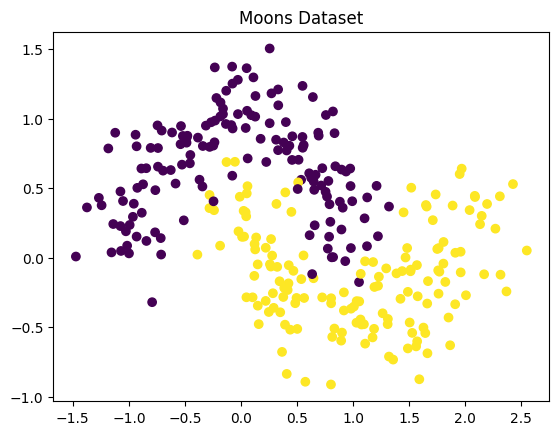

In [3]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons)

plt.title("Moons Dataset")

plt.show()


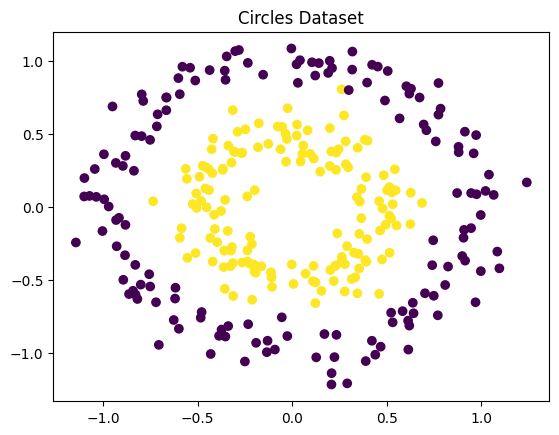

In [4]:
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5)

plt.scatter(X_circles[:,0], X_circles[:,1], c=y_circles)

plt.title("Circles Dataset")

plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [7]:
svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, pred_linear))

Linear Kernel Accuracy: 0.9


In [8]:
svm_poly = SVC(kernel="poly", degree=3)

svm_poly.fit(X_train, y_train)

pred_poly = svm_poly.predict(X_test)

print("Polynomial Kernel Accuracy:", accuracy_score(y_test, pred_poly))

Polynomial Kernel Accuracy: 0.8888888888888888


In [9]:
svm_rbf = SVC(kernel="rbf")

svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, pred_rbf))

RBF Kernel Accuracy: 0.9333333333333333


In [10]:
def plot_decision_boundary(model, X, y, title):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)

    plt.title(title)
    plt.show()

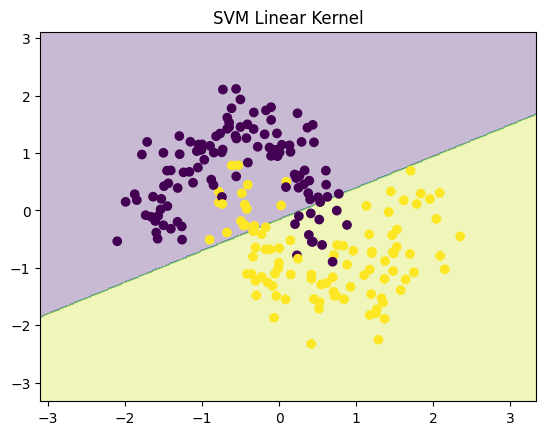

In [11]:
plot_decision_boundary(svm_linear, X_train, y_train, "SVM Linear Kernel")

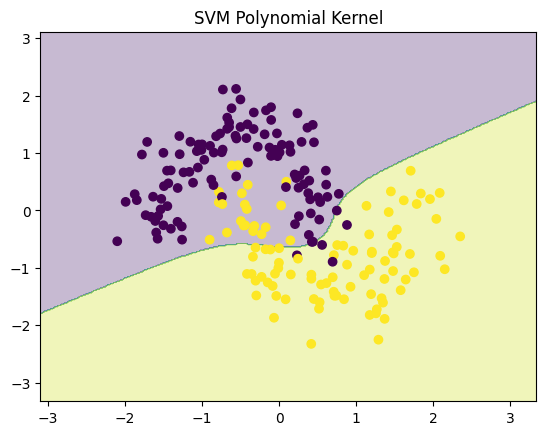

In [12]:
plot_decision_boundary(svm_poly, X_train, y_train, "SVM Polynomial Kernel")

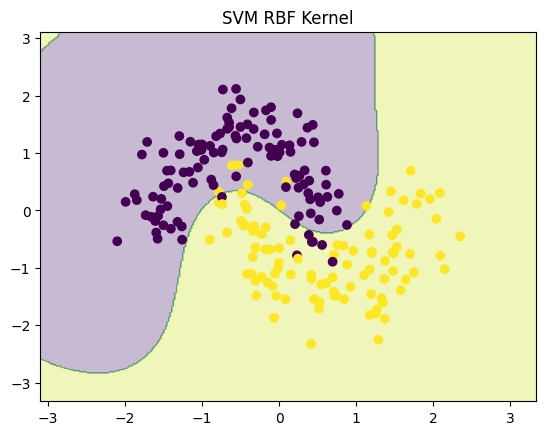

In [13]:
plot_decision_boundary(svm_rbf, X_train, y_train, "SVM RBF Kernel")